In [50]:
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from typing import Optional


In [51]:
@dataclass(frozen=True)
class Benchmark:
    path: str
    meta: dict
    data: Optional[pd.DataFrame]

In [52]:
def load_benchmark(path):
    meta_path = f"{path}/meta.json"

    try:
        with open(meta_path, "r") as file:
            meta = json.load(file)
    except FileNotFoundError:
        print(f"Error: '{meta_path}' file was not found.")
        return None

    csv_path = f"{path}/timing.csv"
    data = None
    try:
        data = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: '{csv_path}' file was not found.")

    return Benchmark(path, meta, data)

In [53]:
def load_benchmarks(root):
    benchmarks = []
    
    for path in root.rglob("*"):
        if path.is_file():
            if path.name == "meta.json":
                benchmark = load_benchmark(path.parent)
                if benchmark is None or benchmark.data is None:
                    print(f"Error loading benchmark '{path.parent}'.")
                else:
                    benchmarks.append(benchmark)

    return benchmarks

In [54]:
def create_benchmark_dataframe(benchmark):
    m = benchmark.meta
    df = benchmark.data.copy()
    df = df.assign(kind=m["kind"])
    df = df.assign(memory=m["memory"])                 # register = subgroups, workgroup = smem
    df = df.assign(n_keys=m["n_keys"])
    df = df.assign(n_segments=m["n_segments"])          # for avg segment size = n_keys / n_segments
    df = df.assign(variant=Path(benchmark.path).parent.name)
    df = df.assign(bin_sampler=m["bin_sampler"])

    # Each measured sample runs the phase kernels *_iterations times inside ONE
    # timed pass, so the GPU-timestamp span covers a whole batch. Divide back to
    # a single-op time. Only the sort phase is iteration-tuned in experiment 2;
    # bin/merge stay at 1 (so they sit near the ~65 us timer floor). us/ms are
    # recomputed from the corrected full-resolution ns.
    bin_it = m.get("bin_iterations", 1) or 1
    sort_it = m.get("sort_iterations", 1) or 1
    merge_it = m.get("merge_iterations", 1) or 1
    df = df.assign(bin_iterations=bin_it, sort_iterations=sort_it, merge_iterations=merge_it)
    for phase, iters in (("bin", bin_it), ("sort", sort_it), ("merge", merge_it)):
        df[f"{phase}_ns"] = df[f"{phase}_ns"] / iters
        df[f"{phase}_us"] = df[f"{phase}_ns"] / 1e3
        df[f"{phase}_ms"] = df[f"{phase}_ns"] / 1e6

    return df

def create_benchmark_meta_dataframe(benchmark):
    df = pd.json_normalize(
        benchmark.meta,
        record_path="bins",
        meta=["n_keys", "n_segments", "kind", "memory"],
        meta_prefix="run_"
    )
    df.insert(0, "bin", range(len(df)))

    return df

In [55]:
benchmarks = load_benchmarks(Path("../output/experiment2"))

In [56]:
data_dfs = [create_benchmark_dataframe(benchmark) for benchmark in benchmarks]
meta_dfs = [create_benchmark_meta_dataframe(benchmark) for benchmark in benchmarks]

data = pd.concat(data_dfs, ignore_index=True)
meta = pd.concat(meta_dfs, ignore_index=True)

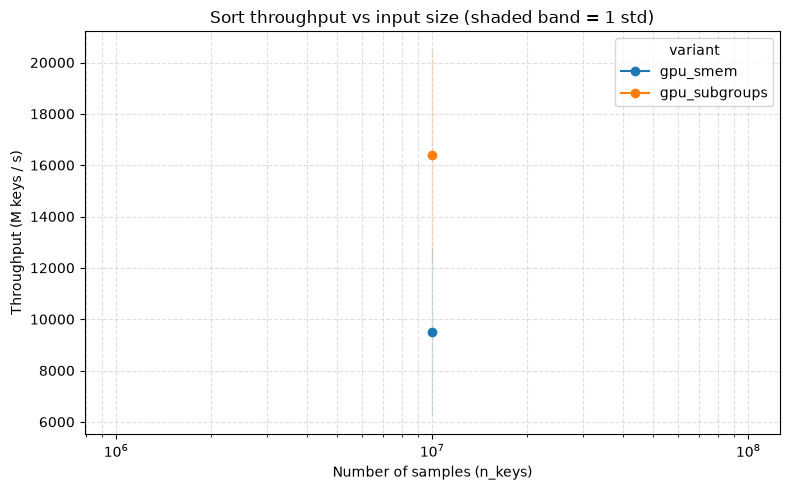

In [57]:
# Sort throughput (keys per second) vs input size, one line per variant.
# Compute throughput per individual run, then aggregate mean +/- std across runs.
plot_df = data.copy()
plot_df = plot_df.loc[plot_df["bin_sampler"] == "bin(3)"]
plot_df["wall_time_ms"] = plot_df["wall_ns"] / 1e6
plot_df["throughput_mkeys_s"] = plot_df["n_keys"] / (plot_df["sort_ns"] / 1e9) / 1e6

summary = (
    plot_df.groupby(["variant", "n_keys"])["throughput_mkeys_s"]
    .agg(mean="mean", std="std")
    .reset_index()
    .sort_values("n_keys")
)

fig, ax = plt.subplots(figsize=(8, 5))

for variant, g in summary.groupby("variant"):
    line, = ax.plot(g["n_keys"], g["mean"], marker="o", label=variant)
    ax.fill_between(
        g["n_keys"], g["mean"] - g["std"], g["mean"] + g["std"],
        color=line.get_color(), alpha=0.2,
    )

ax.set_xscale("log")   # input size spans 4 decades
ax.set_xlabel("Number of samples (n_keys)")
ax.set_ylabel("Throughput (M keys / s)")
ax.set_title("Sort throughput vs input size (shaded band = 1 std)")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(title="variant")

fig.tight_layout()
plt.show()


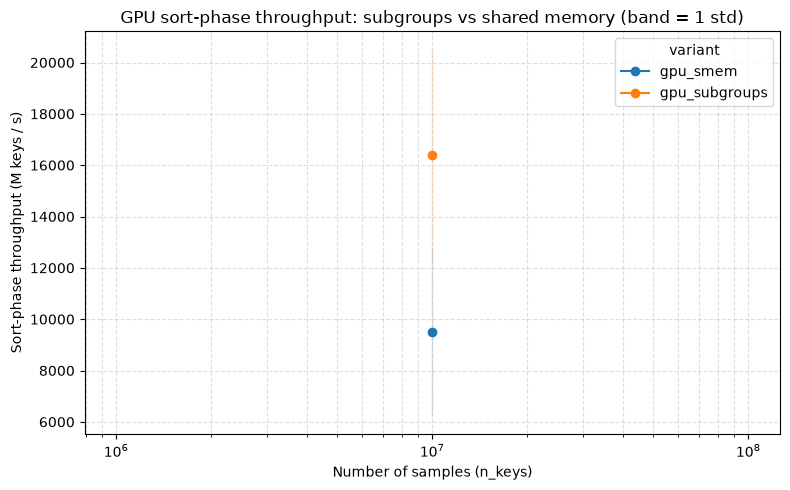

In [58]:
# GPU only: subgroups vs shared memory, measured on the SORT PHASE alone.
# Using sort_ns (not total wall time) isolates the part subgroups actually
# accelerate, so the difference is visible instead of diluted by upload/merge.
gpu_df = plot_df[plot_df["variant"].isin(["gpu_smem", "gpu_subgroups"])].copy()
gpu_df["sort_throughput_mkeys_s"] = gpu_df["n_keys"] / (gpu_df["sort_ns"] / 1e9) / 1e6

gpu_summary = (
    gpu_df.groupby(["variant", "n_keys"])["sort_throughput_mkeys_s"]
    .agg(mean="mean", std="std")
    .reset_index()
    .sort_values("n_keys")
)

fig, ax = plt.subplots(figsize=(8, 5))

for variant, g in gpu_summary.groupby("variant"):
    line, = ax.plot(g["n_keys"], g["mean"], marker="o", label=variant)
    ax.fill_between(
        g["n_keys"], g["mean"] - g["std"], g["mean"] + g["std"],
        color=line.get_color(), alpha=0.2,
    )

ax.set_xscale("log")
ax.set_xlabel("Number of samples (n_keys)")
ax.set_ylabel("Sort-phase throughput (M keys / s)")
ax.set_title("GPU sort-phase throughput: subgroups vs shared memory (band = 1 std)")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(title="variant")

fig.tight_layout()
plt.show()


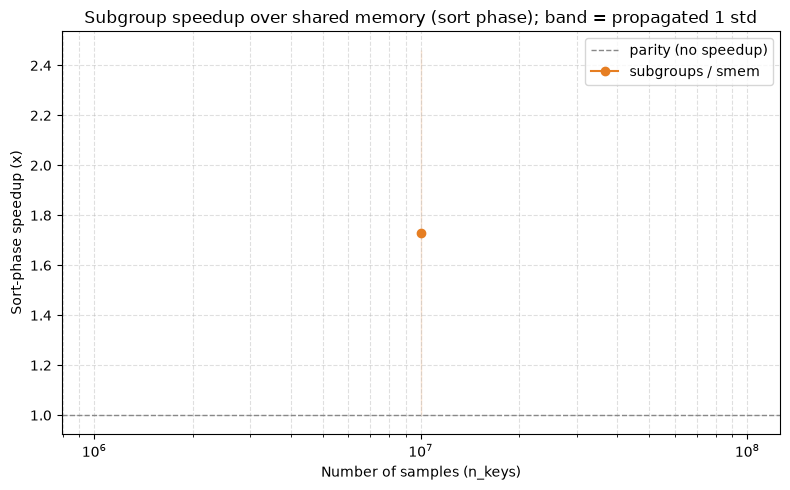

In [59]:
# Subgroups speedup over shared memory on the sort phase: a single curve that
# captures the erosion with size (peaks ~1.4x at mid sizes, decays toward ~1.05x).
# gpu_summary (mean/std of sort-phase throughput per variant/size) comes from the
# previous cell.
pivot_mean = gpu_summary.pivot(index="n_keys", columns="variant", values="mean")
pivot_std = gpu_summary.pivot(index="n_keys", columns="variant", values="std")

ratio = pivot_mean["gpu_subgroups"] / pivot_mean["gpu_smem"]
# Propagate uncertainty for r = a/b:  sigma_r/r = sqrt((sa/a)^2 + (sb/b)^2)
rel_err = (
    (pivot_std["gpu_subgroups"] / pivot_mean["gpu_subgroups"]) ** 2
    + (pivot_std["gpu_smem"] / pivot_mean["gpu_smem"]) ** 2
) ** 0.5
ratio_err = ratio * rel_err

fig, ax = plt.subplots(figsize=(8, 5))

ax.axhline(1.0, color="#888", linestyle="--", linewidth=1, label="parity (no speedup)")
ax.plot(ratio.index, ratio.values, marker="o", color="#e67e22", label="subgroups / smem")
ax.fill_between(
    ratio.index, (ratio - ratio_err).values, (ratio + ratio_err).values,
    color="#e67e22", alpha=0.2,
)

ax.set_xscale("log")
ax.set_xlabel("Number of samples (n_keys)")
ax.set_ylabel("Sort-phase speedup (x)")
ax.set_title("Subgroup speedup over shared memory (sort phase); band = propagated 1 std")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend()

fig.tight_layout()
plt.show()


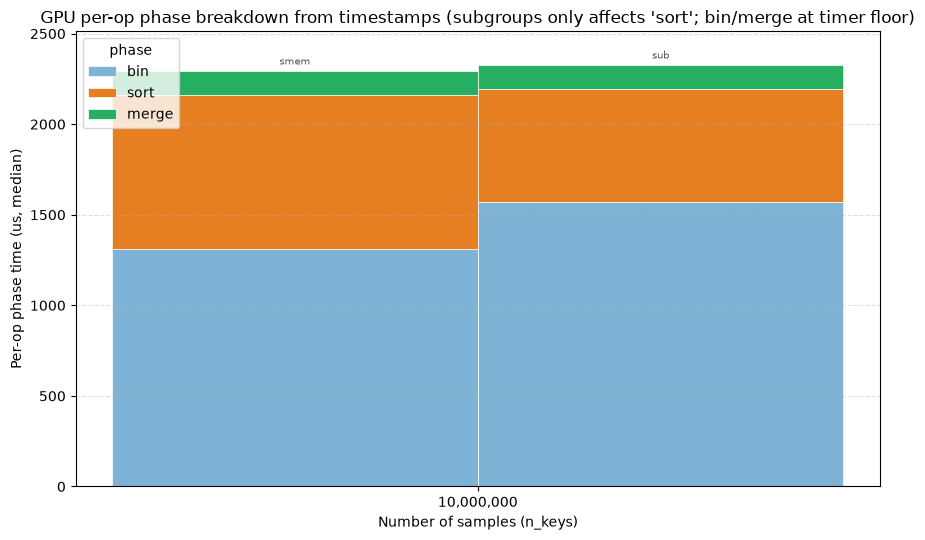

In [60]:
# Per-op phase breakdown per GPU variant per size, from GPU timestamps (median us).
# Shows Amdahl's law: subgroups only shrink the "sort" band; bin is unaffected.
#
# Wall time is deliberately NOT decomposed here. With iteration batching the wall
# span covers a whole batch of sort_iterations sorts, so a single-op wall split is
# meaningless -- the GPU-timestamp phases (each already divided back to one op in
# the loader) are the honest per-op decomposition.
#
# CAVEAT: only the sort phase was iteration-tuned, so its band is resolved well
# below the timer quantum. bin/merge ran once per sample, so they sit at the
# ~65 us timer floor (1-2 ticks) -- read their absolute height as "at or below
# the floor", not as a precise measurement. merge is ~0 real work here (segments
# <= tile size), so any bar it shows is pure quantization.
import numpy as np

phase_src = (
    plot_df[plot_df["variant"].isin(["gpu_smem", "gpu_subgroups"])]
    .groupby(["variant", "n_keys"])[["bin_ns", "sort_ns", "merge_ns"]]
    .median()
    / 1e3   # -> microseconds
)
phase_src.columns = ["bin", "sort", "merge"]

phases = ["bin", "sort", "merge"]
colors = {"bin": "#7fb3d5", "sort": "#e67e22", "merge": "#27ae60"}
variants = ["gpu_smem", "gpu_subgroups"]
sizes = sorted(plot_df["n_keys"].unique())

x = np.arange(len(sizes))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5.5))

for i, variant in enumerate(variants):
    offset = (i - 0.5) * width
    bottom = np.zeros(len(sizes))
    for phase in phases:
        vals = [phase_src.loc[(variant, n), phase] for n in sizes]
        ax.bar(
            x + offset, vals, width, bottom=bottom, color=colors[phase],
            edgecolor="white", linewidth=0.5,
            label=phase if i == 0 else None,
        )
        bottom += vals

# Label each bar with its variant just above the top of the stack.
totals = {n: {v: sum(phase_src.loc[(v, n), p] for p in phases) for v in variants}
          for n in sizes}
maxh = max(t for n in sizes for t in totals[n].values())
for i, variant in enumerate(variants):
    offset = (i - 0.5) * width
    short = "sub" if variant == "gpu_subgroups" else "smem"
    for xi, n in zip(x, sizes):
        ax.text(xi + offset, totals[n][variant] + 0.01 * maxh, short,
                ha="center", va="bottom", fontsize=7, color="#555")

ax.set_ymargin(0.08)
ax.set_xticks(x)
ax.set_xticklabels([f"{n:,}" for n in sizes])
ax.set_xlabel("Number of samples (n_keys)")
ax.set_ylabel("Per-op phase time (us, median)")
ax.set_title("GPU per-op phase breakdown from timestamps "
             "(subgroups only affects 'sort'; bin/merge at timer floor)")
ax.legend(title="phase", loc="upper left")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

In [61]:
# ---------------------------------------------------------------------------
# Sort-phase throughput across ALL bins (segment sizes), both GPU variants and
# every key count -- the joined table both charts below draw from.
#
# Segment size N is the axis where the subgroup-vs-smem effect actually lives,
# so we key on it directly. bin(k) sorts tiles of size N = 2**(k-1). Throughput
# is computed per run then reduced with the MEDIAN: the GPU timer is quantized
# (~65 us ticks), which makes the mean lumpy, so the median is the honest center.
#
# bin(1) / N=1 is excluded here: size-1 segments are already sorted, so the sort
# kernel is a pure no-op whose "throughput" is a meaningless timer-floor spike.
# Dropping it at the source keeps it out of every downstream plot and table.
# ---------------------------------------------------------------------------
import numpy as np

seg = data[data["variant"].isin(["gpu_smem", "gpu_subgroups"])].copy()
seg["N"] = (seg["bin_sampler"].str.extract(r"bin\((\d+)\)").astype(int) - 1).rpow(2)
seg = seg[seg["sort_ns"] > 0]                          # drop unmeasurable ticks
seg = seg[seg["N"] > 1]                                # drop bin(1)/N=1 (size-1 no-op)
seg["sort_throughput_mkeys_s"] = seg["n_keys"] / (seg["sort_ns"] / 1e9) / 1e6

sort_summary = (
    seg.groupby(["variant", "n_keys", "N"])["sort_throughput_mkeys_s"]
    .median()
    .reset_index()
)

# Wide by variant so both charts share one prepared frame.
tp = sort_summary.pivot_table(
    index=["n_keys", "N"], columns="variant", values="sort_throughput_mkeys_s"
).reset_index()
tp["speedup"] = tp["gpu_subgroups"] / tp["gpu_smem"]   # >1 => subgroups win

METHOD_COLORS = {"gpu_subgroups": "#4269d0", "gpu_smem": "#e8834a"}
METHOD_LABELS = {"gpu_subgroups": "subgroups", "gpu_smem": "shared memory"}
key_counts = sorted(tp["n_keys"].unique())
seg_sizes = sorted(tp["N"].unique())
tp.head()


variant,n_keys,N,gpu_smem,gpu_subgroups,speedup
0,10000000,2,15258.789062,16954.210069,1.111111
1,10000000,4,11737.530048,16106.499566,1.372222
2,10000000,8,4768.371582,16106.499566,3.377778
3,10000000,16,8053.249783,14565.207741,1.808612
4,10000000,32,5209.887469,6357.828776,1.220339


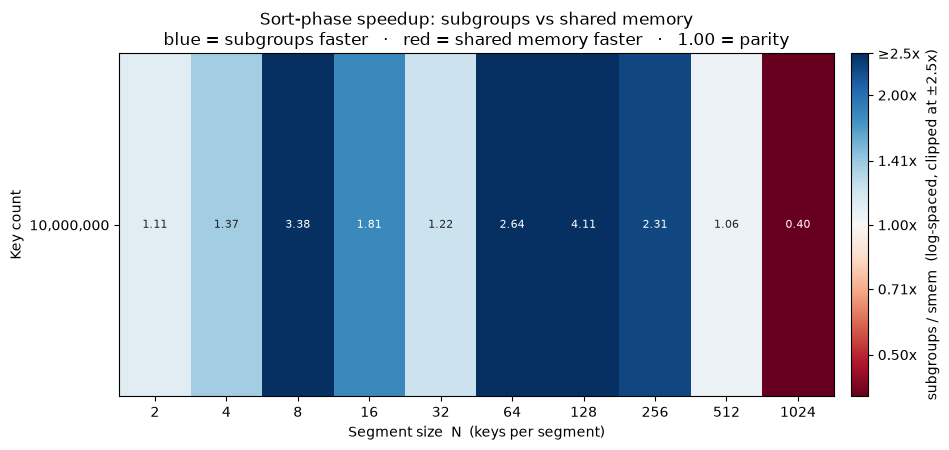

In [62]:
# ===========================================================================
# HEADLINE: where do subgroups win? Diverging heatmap of the sort-phase speedup
# (subgroup throughput / smem throughput) over segment size x key count.
#
#   blue  = subgroups faster   red = shared memory faster   white = parity (1.0)
#
# One figure carries all four variables: N on x, key count on y, method folded
# into the ratio, throughput folded into color. Coloring is symmetric in
# log2(ratio) so a 2x win and a 2x loss are equally saturated.
#
# The color scale saturates at +/-2.5x. The N=1024 register-spill corner runs
# far past that (down to ~0.07x at low key counts) -- letting it set the limit
# would flatten the whole mid-band, so those cells clip to deep red instead.
# Their true ratio is still printed in the cell, so nothing is hidden.
# ===========================================================================
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as mticker

Z = (
    tp.pivot(index="n_keys", columns="N", values="speedup")
    .reindex(index=key_counts, columns=seg_sizes)
)
logZ = np.log2(Z.values)
lim = float(np.log2(2.5))                              # saturate beyond +/-2.5x
norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.imshow(logZ, cmap="RdBu", norm=norm, aspect="auto")

# Annotate each cell with the raw ratio; white ink on saturated cells.
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        r = Z.values[i, j]
        if np.isnan(r):
            continue
        ink = "white" if abs(logZ[i, j]) > 0.6 * lim else "#222"
        ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=8, color=ink)

ax.set_xticks(range(len(seg_sizes)))
ax.set_xticklabels([f"{n}" for n in seg_sizes])
ax.set_yticks(range(len(key_counts)))
ax.set_yticklabels([f"{n:,}" for n in key_counts])
ax.set_xlabel("Segment size  N  (keys per segment)")
ax.set_ylabel("Key count")
ax.set_title("Sort-phase speedup: subgroups vs shared memory\n"
             "blue = subgroups faster   ·   red = shared memory faster   ·   1.00 = parity")

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_ticks(np.log2([0.5, 0.71, 1.0, 1.41, 2.0, 2.5]))
cbar.ax.set_yticklabels(["0.50x", "0.71x", "1.00x", "1.41x", "2.00x", "≥2.5x"])
cbar.set_label("subgroups / smem  (log-spaced, clipped at ±2.5x)")

fig.tight_layout()
plt.show()

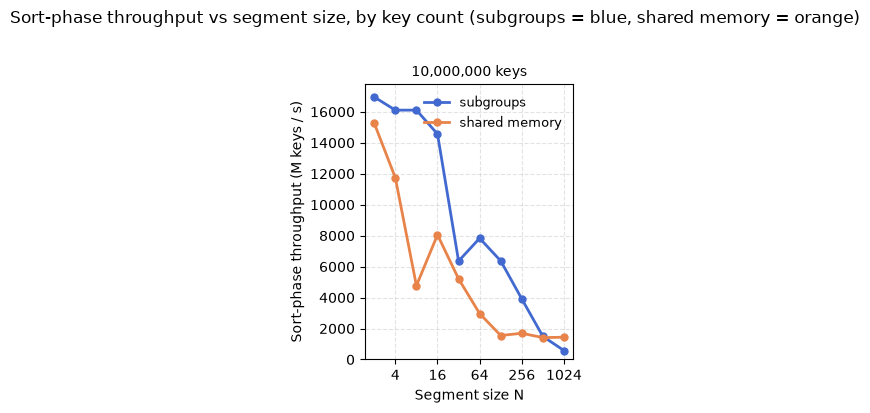

In [63]:
# ===========================================================================
# DETAIL: absolute sort-phase throughput vs segment size, one panel per key
# count (small multiples). The ratio heatmap hides magnitudes; this keeps them.
#
# Each panel autoscales its own y -- throughput grows ~10x per key-count decade
# (more segments amortize fixed cost), so a shared axis would flatten the small
# panels to nothing. The heatmap already carries the cross-panel comparison; the
# job here is the within-panel shape.
#
# Read within a panel -> the per-N crossover: subgroups (blue) win through the
# middle and lose hard at N=1024. Small-key panels wobble: that is the ~65 us
# timer floor, not signal. (N=1/bin(1) is excluded upstream as a no-op.)
# ===========================================================================
ncols = len(key_counts)
fig, axes = plt.subplots(1, ncols, figsize=(3.2 * ncols, 4.0), sharex=True)
axes = np.atleast_1d(axes)

for ax, nk in zip(axes, key_counts):
    for variant in ("gpu_subgroups", "gpu_smem"):
        g = (sort_summary[(sort_summary["variant"] == variant)
                          & (sort_summary["n_keys"] == nk)]
             .sort_values("N"))
        ax.plot(g["N"], g["sort_throughput_mkeys_s"], marker="o", markersize=5,
                linewidth=2, color=METHOD_COLORS[variant], label=METHOD_LABELS[variant])
    ax.set_xscale("log", base=2)
    ax.set_ylim(bottom=0)
    ax.set_title(f"{nk:,} keys", fontsize=10)
    ax.grid(True, which="both", linestyle="--", alpha=0.35)
    ax.set_xlabel("Segment size N")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v)}"))

axes[0].set_ylabel("Sort-phase throughput (M keys / s)")
axes[0].legend(frameon=False, fontsize=9, loc="upper right")

fig.suptitle("Sort-phase throughput vs segment size, by key count "
             "(subgroups = blue, shared memory = orange)", y=1.02)
fig.tight_layout()
plt.show()


In [64]:
# ===========================================================================
# TABLE: median sort-phase throughput (M keys/s) for every bin x memory x key
# count. Rows are the segment-size bin (N = 2**(bin-1)); columns pair each key count
# with the two sort backends (subgroups = register, smem = workgroup). Draws
# from sort_summary (per-cell medians) computed in the prep cell above.
#
# Also written tidy to output/experiment2/throughput_summary.csv for reuse
# (e.g. a normalized comparison against bb_segsort).
# ===========================================================================
tbl = sort_summary.copy()
tbl["bin"] = np.log2(tbl["N"]).round().astype(int) + 1      # k such that N = 2**(k-1)
tbl["method"] = tbl["variant"].map({"gpu_subgroups": "subgroups", "gpu_smem": "smem"})

# Tidy long form -> CSV (full precision, one row per bin/method/key count).
tidy = (
    tbl[["bin", "N", "method", "n_keys", "sort_throughput_mkeys_s"]]
    .rename(columns={"sort_throughput_mkeys_s": "throughput_mkeys_s"})
    .sort_values(["bin", "method", "n_keys"])
    .reset_index(drop=True)
)
csv_path = Path("../output/experiment2/throughput_summary.csv")
tidy.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(tidy)} rows)")

# Wide, human-readable grid: bin/N x (key count, method).
wide = (
    tbl.pivot_table(
        index=["bin", "N"],
        columns=["n_keys", "method"],
        values="sort_throughput_mkeys_s",
    )
    .round(1)
    .sort_index()
)
wide.columns.names = ["n_keys", "method"]
print("\nMedian sort-phase throughput (M keys/s):")
wide

wrote ../output/experiment2/throughput_summary.csv  (20 rows)

Median sort-phase throughput (M keys/s):


n_keys   10000000          
method       smem subgroups
bin N                      
2   2     15258.8   16954.2
3   4     11737.5   16106.5
4   8      4768.4   16106.5
5   16     8053.2   14565.2
6   32     5209.9    6357.8
7   64     2965.4    7830.2
8   128    1549.2    6368.9
9   256    1695.4    3912.5
10  512    1413.0    1493.0
11  1024   1439.5     578.0

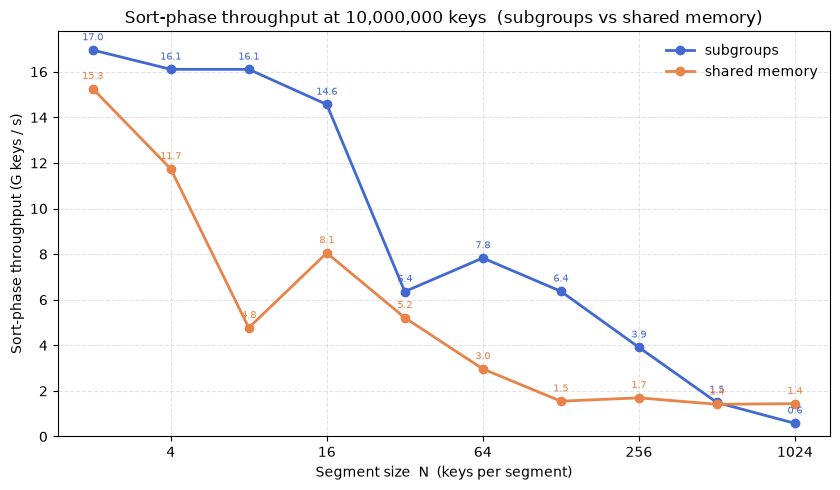

In [65]:
# ===========================================================================
# LARGEST INPUT ONLY (10M keys), throughput in G keys/s. This is the most
# GPU-saturated row -- and the one directly comparable to bb_segsort's reg-sort
# figure (Hou et al. Fig 9), which is also reported in G elements/s. Scaling to
# G/s (M/s / 1000) puts the magnitudes on the same footing as that paper.
# ===========================================================================
import matplotlib.ticker as mticker

NK = 10_000_000
g10 = sort_summary[sort_summary["n_keys"] == NK].copy()
g10["throughput_gkeys_s"] = g10["sort_throughput_mkeys_s"] / 1e3   # M/s -> G/s

fig, ax = plt.subplots(figsize=(8.5, 5.0))

for variant in ("gpu_subgroups", "gpu_smem"):
    g = g10[g10["variant"] == variant].sort_values("N")
    ax.plot(g["N"], g["throughput_gkeys_s"], marker="o", markersize=6, linewidth=2,
            color=METHOD_COLORS[variant], label=METHOD_LABELS[variant])
    # annotate each point with its G/s value
    for _, row in g.iterrows():
        ax.annotate(f"{row['throughput_gkeys_s']:.1f}",
                    (row["N"], row["throughput_gkeys_s"]),
                    textcoords="offset points", xytext=(0, 7),
                    ha="center", fontsize=7, color=METHOD_COLORS[variant])

ax.set_xscale("log", base=2)
ax.set_ylim(bottom=0)
ax.set_xlabel("Segment size  N  (keys per segment)")
ax.set_ylabel("Sort-phase throughput (G keys / s)")
ax.set_title(f"Sort-phase throughput at {NK:,} keys  (subgroups vs shared memory)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(frameon=False, fontsize=10)

fig.tight_layout()
plt.show()

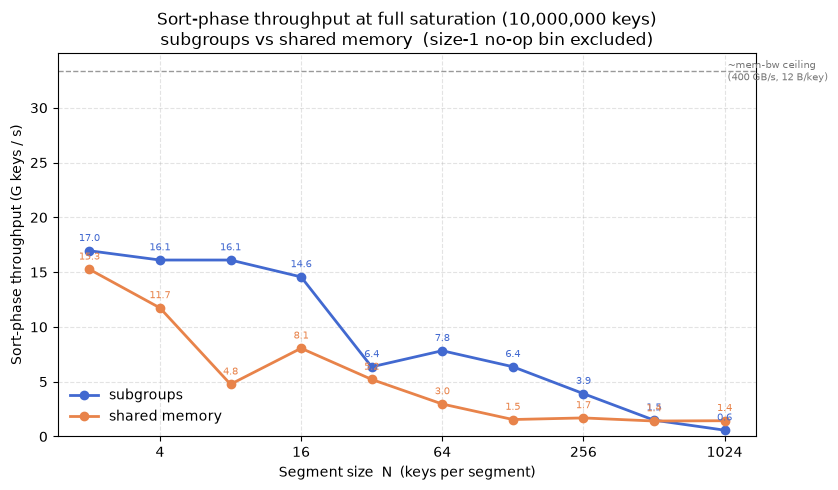

In [66]:
# ===========================================================================
# FULL SATURATION: the largest budget in the sweep (2^28 = 268,435,456 keys,
# bb_segsort's dataset size), throughput in G keys/s vs segment size. Filtered
# straight out of `data` -- the regime most comparable to Hou et al.'s reg-sort
# figure (Fig 9).
#
# We drop the degenerate bin where average segment size is ~1: size-1 segments
# are already sorted, so the sort kernel is a pure no-op (implied bandwidth in
# the tens of thousands of GB/s). Its "throughput" is meaningless and would
# flatten the axis.
#
# The dashed line is a conservative memory-bandwidth ceiling (400 GB/s at
# 12 B/key: read key + write key + write value index). NOTE: the small-mid bins
# sit slightly ABOVE it and stay there even with sort_iterations=1 (no batching),
# so this is NOT a re-sort/caching artifact -- either the effective traffic is
# nearer 8 B/key (ceiling ~50 G/s, which would make them physical) or the
# small-segment path is genuinely doing less global traffic. Treat these
# near-ceiling values as "peak-efficiency, exact number pending a traffic-model
# check"; the N>=32 bins are unambiguously physical.
# ===========================================================================
NK = int(data["n_keys"].max())

lseg = data[(data["variant"].isin(["gpu_smem", "gpu_subgroups"]))
            & (data["n_keys"] == NK)].copy()
lseg["N"] = (lseg["bin_sampler"].str.extract(r"bin\((\d+)\)").astype(int) - 1).rpow(2)
lseg["avg_seg"] = lseg["n_keys"] / lseg["n_segments"]
lseg = lseg[(lseg["sort_ns"] > 0) & (lseg["avg_seg"] > 1.0)]   # drop size-1 no-op
lseg["throughput_gkeys_s"] = lseg["n_keys"] / (lseg["sort_ns"] / 1e9) / 1e9

lsum = (
    lseg.groupby(["variant", "N"])["throughput_gkeys_s"]
    .median()
    .reset_index()
)
CEIL_GKEYS = 400e9 / 12 / 1e9   # ~400 GB/s / 12 B per key -> G keys/s

fig, ax = plt.subplots(figsize=(8.5, 5.0))

ax.axhline(CEIL_GKEYS, color="#999", linestyle="--", linewidth=1)
ax.text(lsum["N"].max(), CEIL_GKEYS, " ~mem-bw ceiling\n (400 GB/s, 12 B/key)",
        va="center", ha="left", fontsize=7, color="#777")

for variant in ("gpu_subgroups", "gpu_smem"):
    g = lsum[lsum["variant"] == variant].sort_values("N")
    ax.plot(g["N"], g["throughput_gkeys_s"], marker="o", markersize=6, linewidth=2,
            color=METHOD_COLORS[variant], label=METHOD_LABELS[variant])
    for _, row in g.iterrows():
        ax.annotate(f"{row['throughput_gkeys_s']:.1f}",
                    (row["N"], row["throughput_gkeys_s"]),
                    textcoords="offset points", xytext=(0, 7),
                    ha="center", fontsize=7, color=METHOD_COLORS[variant])

ax.set_xscale("log", base=2)
ax.set_ylim(bottom=0)
ax.set_xlabel("Segment size  N  (keys per segment)")
ax.set_ylabel("Sort-phase throughput (G keys / s)")
ax.set_title(f"Sort-phase throughput at full saturation ({NK:,} keys)\n"
             "subgroups vs shared memory  (size-1 no-op bin excluded)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(frameon=False, fontsize=10)

fig.tight_layout()
plt.show()